In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels scikit-posthocs shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from scipy import stats
import scikit_posthocs as sp
import shap
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_FILE = os.path.join(OUTPUT_DIR, "Experiment_Statistical_Results.txt")

os.makedirs(FIGURES_DIR, exist_ok=True)

# Clear log file
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS STATISTICAL RESULTS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_V2_scored.csv"))
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_V2_scored.csv"))
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_V2_scored.csv"))

# Drop missing values
df_orig = df_orig.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_a = df_dist_a.dropna(subset=['codebert_score', 'adak_index']).copy()
df_dist_b = df_dist_b.dropna(subset=['codebert_score', 'adak_index']).copy()

# Add needed features
token_col = 'code_token_length' if 'code_token_length' in df_orig.columns else 'token_count'
for df in[df_orig, df_dist_a, df_dist_b]:
    df['comment_word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    df['code_token_length'] = df[token_col]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})
log_result("Setup Complete. Data loaded.")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup Complete. Data loaded.



Test A: Swapped Distractors (Binary)

Test B: Shuffled Distractors (Binary)


C:\Users\HP\AppData\Local\Temp\ipykernel_17380\4077769500.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_a, ax=axes[0,0], palette='Blues')
C:\Users\HP\AppData\Local\Temp\ipykernel_17380\4077769500.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_b, ax=axes[0,1], palette='Reds')


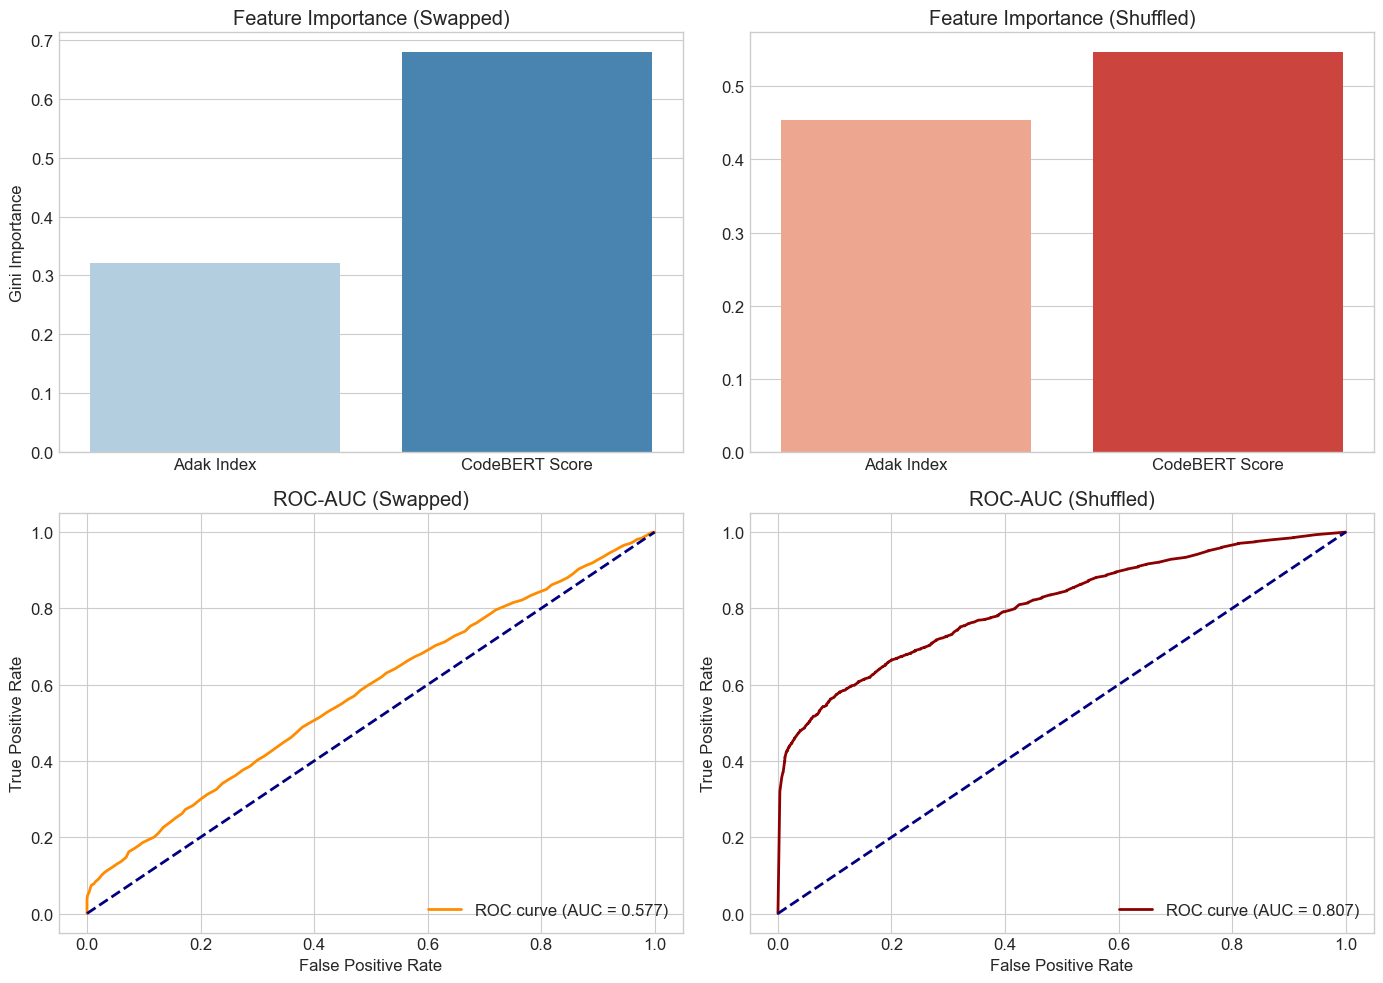

In [2]:
def run_binary_rf(df_real, df_fake, experiment_name):
    log_result(f"\n{'='*50}\n{experiment_name} (Binary)\n{'='*50}")
    
    # Assign labels (1=Valid, 0=Distractor)
    df_real_copy = df_real.copy()
    df_fake_copy = df_fake.copy()
    df_real_copy['label'] = 1
    df_fake_copy['label'] = 0
    
    df_combined = pd.concat([df_real_copy, df_fake_copy], ignore_index=True)
    X = df_combined[['adak_index', 'codebert_score']]
    y = df_combined['label']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    y_prob = rf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    return rf.feature_importances_, fpr, tpr, auc(fpr, tpr)

imp_a, fpr_a, tpr_a, auc_a = run_binary_rf(df_orig, df_dist_a, "Test A: Swapped Distractors")
imp_b, fpr_b, tpr_b, auc_b = run_binary_rf(df_orig, df_dist_b, "Test B: Shuffled Distractors")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 & 2. Gini Importance Bars
sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_a, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Feature Importance (Swapped)')
axes[0,0].set_ylabel('Gini Importance')

sns.barplot(x=['Adak Index', 'CodeBERT Score'], y=imp_b, ax=axes[0,1], palette='Reds')
axes[0,1].set_title('Feature Importance (Shuffled)')

# 3 & 4. ROC-AUC Curves
axes[1,0].plot(fpr_a, tpr_a, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_a:.3f})')
axes[1,0].plot([0, 1],[0, 1], color='navy', lw=2, linestyle='--')
axes[1,0].set_title('ROC-AUC (Swapped)')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend(loc="lower right")

axes[1,1].plot(fpr_b, tpr_b, color='darkred', lw=2, label=f'ROC curve (AUC = {auc_b:.3f})')
axes[1,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1,1].set_title('ROC-AUC (Shuffled)')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_Binary_ROC_and_Gini.png"), dpi=300, bbox_inches='tight')
plt.show()


Experiment 1: 3-Class Multi-Feature Analysis & SHAP
--- Multi-Feature Model Classification Report ---
              precision    recall  f1-score   support

 Swapped (0)       0.52      0.49      0.51      2400
   Valid (1)       0.46      0.43      0.45      2400
Shuffled (2)       0.68      0.76      0.72      2400

    accuracy                           0.56      7200
   macro avg       0.56      0.56      0.56      7200
weighted avg       0.56      0.56      0.56      7200



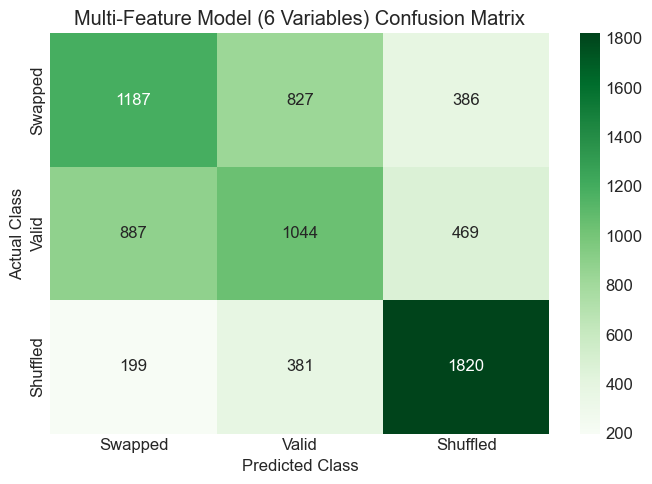

Calculating SHAP values... (this takes a moment)


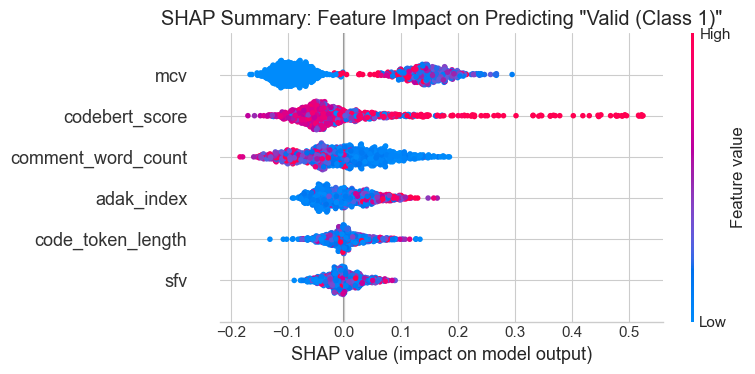

SHAP analysis completed and plot saved.


In [4]:
log_result(f"\n{'='*50}\nExperiment 1: 3-Class Multi-Feature Analysis & SHAP\n{'='*50}")

# 1. Prepare the 3-Class dataset
df_orig['label'] = 1
df_dist_a['label'] = 0
df_dist_b['label'] = 2

df_combined = pd.concat([df_orig, df_dist_a, df_dist_b], ignore_index=True)
features =['adak_index', 'codebert_score', 'mcv', 'sfv', 'comment_word_count', 'code_token_length']

X = df_combined[features]
y = df_combined['label']

# Split the data
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train the model
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_multi.fit(X_train_B, y_train_B)
y_pred_B = rf_multi.predict(X_test_B)

log_result("--- Multi-Feature Model Classification Report ---")
log_result(classification_report(y_test_B, y_pred_B, target_names=['Swapped (0)', 'Valid (1)', 'Shuffled (2)']))

# 2. Multi-Class Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test_B, y_pred_B), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Swapped', 'Valid', 'Shuffled'], yticklabels=['Swapped', 'Valid', 'Shuffled'])
plt.title('Multi-Feature Model (6 Variables) Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_MultiClass_ConfusionMatrix.png"), dpi=300, bbox_inches='tight')
plt.show()

# 3. SHAP Analysis
print("Calculating SHAP values... (this takes a moment)")
# Take a sample so SHAP calculates quickly
X_test_sample = X_test_B.sample(1000, random_state=42)
explainer = shap.TreeExplainer(rf_multi)
shap_values = explainer.shap_values(X_test_sample)

# Handle different versions of the SHAP library output automatically
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]  # Older SHAP versions return a list
else:
    shap_to_plot = shap_values[:, :, 1]  # Newer SHAP versions return a 3D array

# Plot SHAP for Class 1 (Predicting the Valid Comments)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test_sample, show=False)
plt.title('SHAP Summary: Feature Impact on Predicting "Valid (Class 1)"')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_SHAP_Summary.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("SHAP analysis completed and plot saved.")


Experiment 2: Paradigm Bias (Kruskal-Wallis)
Kruskal-Wallis Results:
H-Statistic: 686.6990 | p-value: 7.6773e-150

Dunn's Post-Hoc Test:
                 Object-Oriented     Procedural      Scripting
Object-Oriented     1.000000e+00  1.355621e-124   1.000000e+00
Procedural         1.355621e-124   1.000000e+00  4.400879e-133
Scripting           1.000000e+00  4.400879e-133   1.000000e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_17380\1320484985.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='paradigm', y='adak_index', data=df_orig, showfliers=False, palette='Set2')


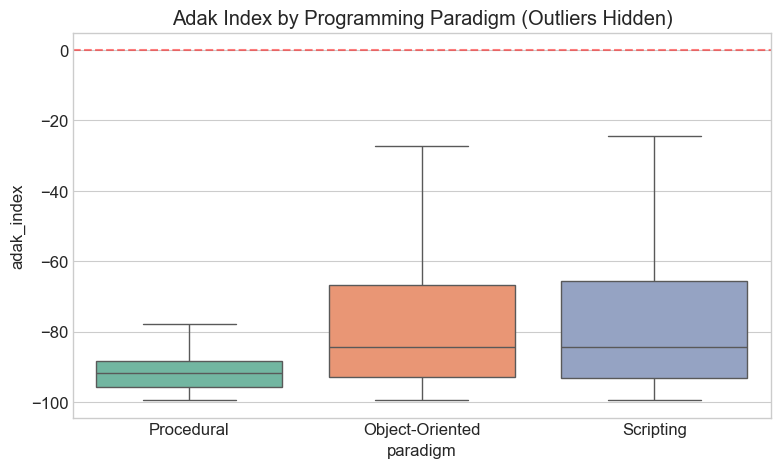

C:\Users\HP\AppData\Local\Temp\ipykernel_17380\1320484985.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='language', y='adak_index', data=df_orig, palette='Set3', ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_17380\1320484985.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='language', y='codebert_score', data=df_orig, palette='Set3', ax=axes[1])


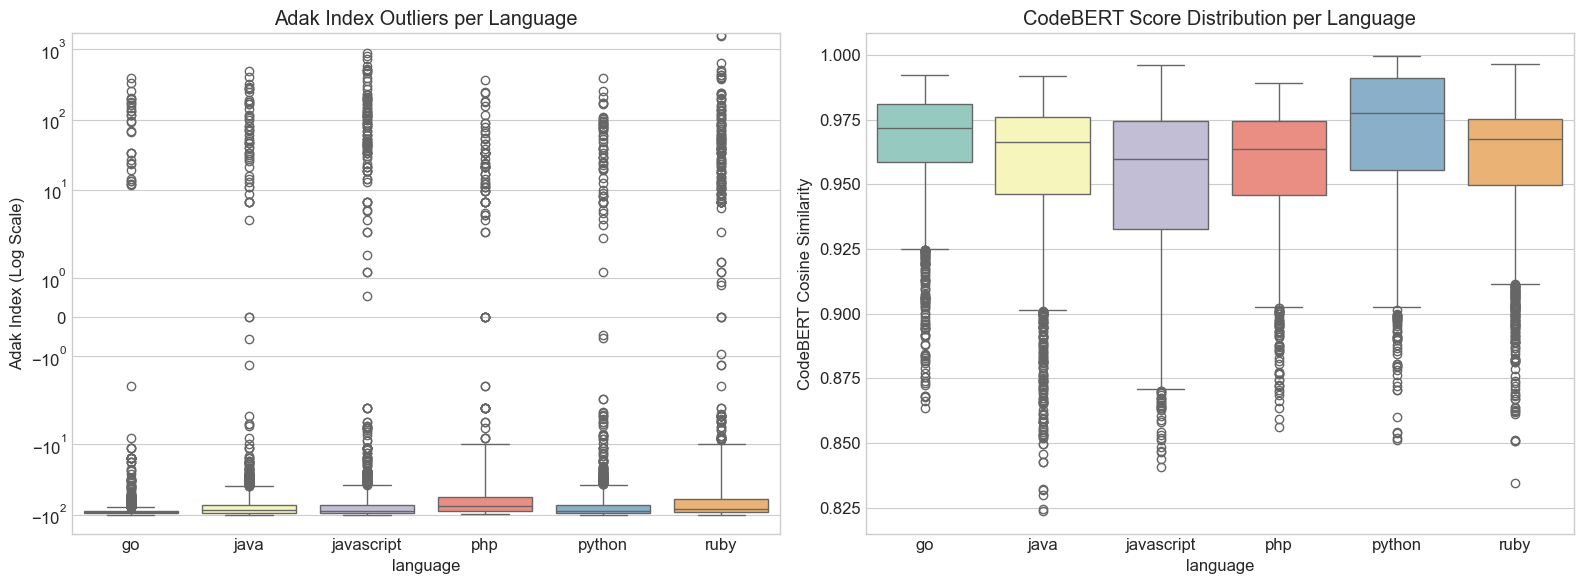

In [5]:
log_result(f"\n{'='*50}\nExperiment 2: Paradigm Bias (Kruskal-Wallis)\n{'='*50}")

paradigm_map = {'java': 'Object-Oriented', 'ruby': 'Object-Oriented', 'go': 'Procedural',
                'python': 'Scripting', 'javascript': 'Scripting', 'php': 'Scripting'}
df_orig['paradigm'] = df_orig['language'].str.lower().map(paradigm_map)

# Kruskal-Wallis Test
paradigms = df_orig['paradigm'].dropna().unique()
adak_groups = [df_orig[df_orig['paradigm'] == p]['adak_index'] for p in paradigms]

h_stat, p_value = stats.kruskal(*adak_groups)
log_result(f"Kruskal-Wallis Results:\nH-Statistic: {h_stat:.4f} | p-value: {p_value:.4e}\n")

if p_value < 0.05:
    dunn_results = sp.posthoc_dunn(df_orig, val_col='adak_index', group_col='paradigm', p_adjust='bonferroni')
    log_result("Dunn's Post-Hoc Test:\n" + str(dunn_results))

# 1. Paradigm Boxplot (Cleaned for visibility)
plt.figure(figsize=(9, 5))
sns.boxplot(x='paradigm', y='adak_index', data=df_orig, showfliers=False, palette='Set2')
plt.title('Adak Index by Programming Paradigm (Outliers Hidden)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.savefig(os.path.join(FIGURES_DIR, "Exp2_Paradigm_Boxplot.png"), dpi=300, bbox_inches='tight')
plt.show()

# 2. Individual Language Whisker Plots (Showing Outliers via SymLog)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='language', y='adak_index', data=df_orig, palette='Set3', ax=axes[0])
axes[0].set_title('Adak Index Outliers per Language')
axes[0].set_yscale('symlog') # Handles the massive outliers without flat-lining the boxes
axes[0].set_ylabel('Adak Index (Log Scale)')

sns.boxplot(x='language', y='codebert_score', data=df_orig, palette='Set3', ax=axes[1])
axes[1].set_title('CodeBERT Score Distribution per Language')
axes[1].set_ylabel('CodeBERT Cosine Similarity')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp2_Language_Whisker_Plots.png"), dpi=300, bbox_inches='tight')
plt.show()


Experiment 3: Complexity Threshold Analysis
Spearman Correlation by Complexity Segment:
Bucket: Small (SFV < 15) (n=6002) | Corr: 0.0811 (p=3.2031e-10)
Bucket: Medium (SFV 15-40) (n=4387) | Corr: 0.6613 (p=0.0000e+00)
Bucket: Large (SFV > 40) (n=1611) | Corr: 0.8332 (p=0.0000e+00)


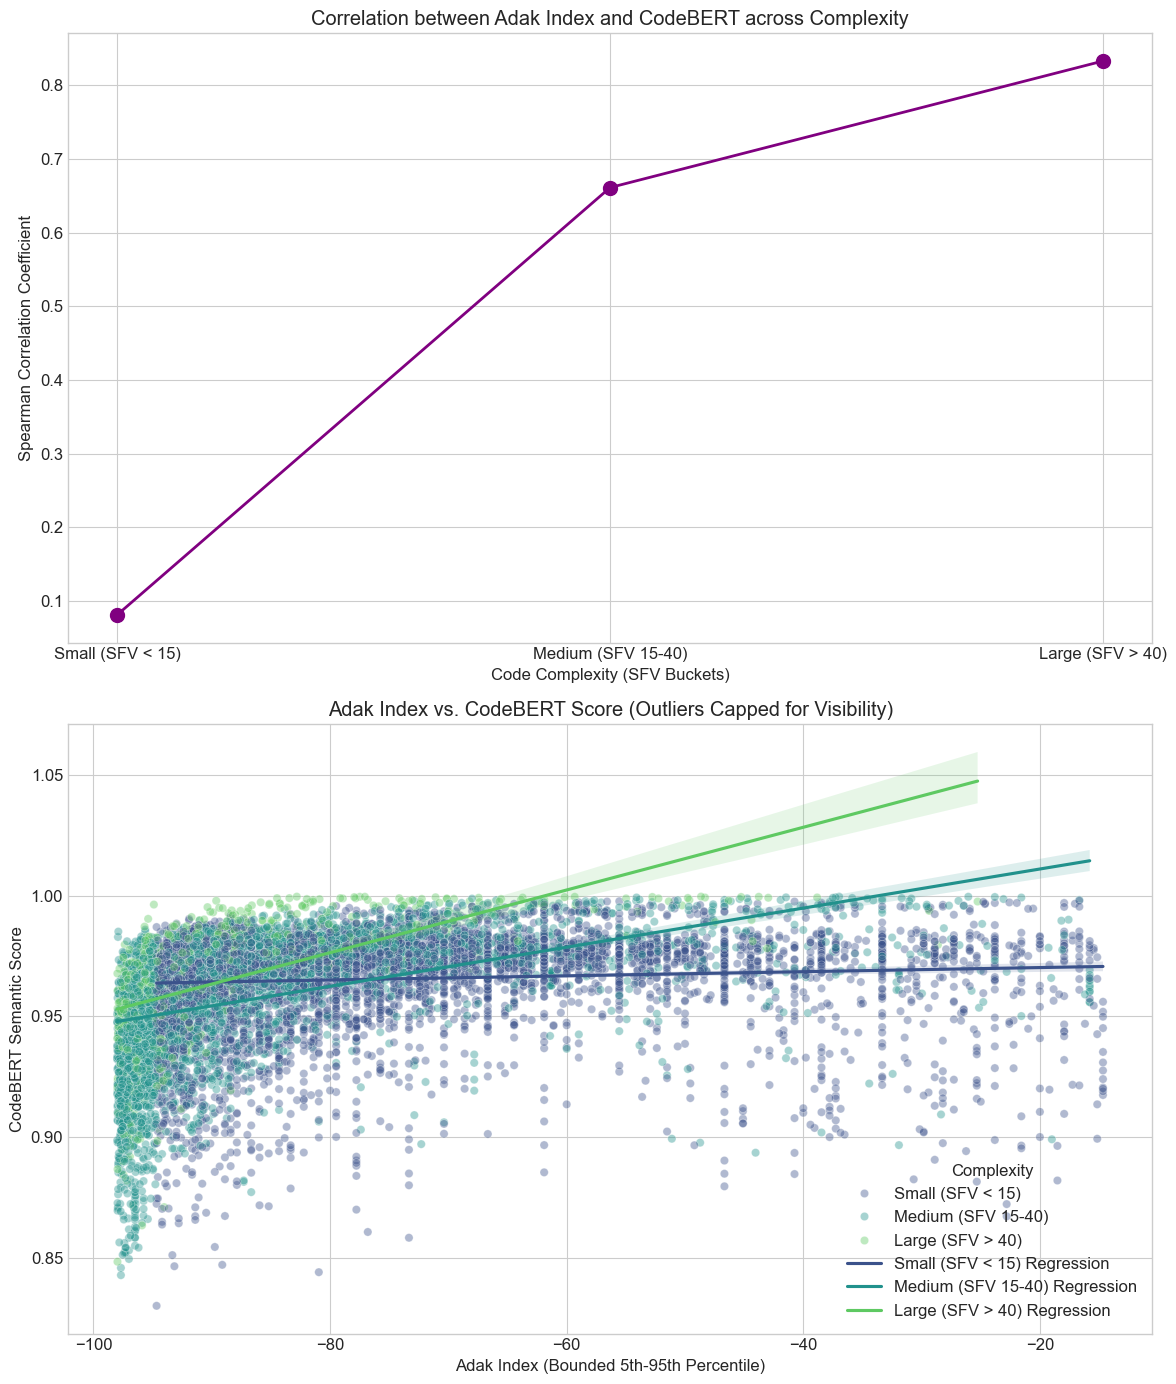

In [6]:
log_result(f"\n{'='*50}\nExperiment 3: Complexity Threshold Analysis\n{'='*50}")

bins =[0, 15, 40, np.inf]
labels =['Small (SFV < 15)', 'Medium (SFV 15-40)', 'Large (SFV > 40)']
df_orig['complexity_bucket'] = pd.cut(df_orig['sfv'], bins=bins, labels=labels)

correlations =[]
log_result("Spearman Correlation by Complexity Segment:")
for bucket in labels:
    subset = df_orig[df_orig['complexity_bucket'] == bucket]
    if len(subset) > 1:
        corr, p_val = stats.spearmanr(subset['adak_index'], subset['codebert_score'])
        correlations.append(corr)
        log_result(f"Bucket: {bucket} (n={len(subset)}) | Corr: {corr:.4f} (p={p_val:.4e})")
    else:
        correlations.append(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# 1. Degradation Curve
axes[0].plot(labels, correlations, marker='o', color='purple', linewidth=2, markersize=10)
axes[0].set_title('Correlation between Adak Index and CodeBERT across Complexity')
axes[0].set_xlabel('Code Complexity (SFV Buckets)')
axes[0].set_ylabel('Spearman Correlation Coefficient')
axes[0].grid(True)

# 2. Scatter Plots with Regression
# Cap the X-axis for visual clarity (to avoid graph crushing)
adak_lower, adak_upper = df_orig['adak_index'].quantile([0.05, 0.95])
filtered_df = df_orig[(df_orig['adak_index'] >= adak_lower) & (df_orig['adak_index'] <= adak_upper)]

sns.scatterplot(data=filtered_df, x='adak_index', y='codebert_score', hue='complexity_bucket', 
                palette='viridis', alpha=0.4, ax=axes[1])

colors = sns.color_palette('viridis', 3)
for idx, bucket in enumerate(labels):
    bucket_data = filtered_df[filtered_df['complexity_bucket'] == bucket]
    if len(bucket_data) > 1:
        sns.regplot(data=bucket_data, x='adak_index', y='codebert_score', 
                    scatter=False, ax=axes[1], line_kws={'color': colors[idx]}, label=f'{bucket} Regression')

axes[1].set_title('Adak Index vs. CodeBERT Score (Outliers Capped for Visibility)')
axes[1].set_xlabel('Adak Index (Bounded 5th-95th Percentile)')
axes[1].set_ylabel('CodeBERT Semantic Score')
axes[1].legend(title='Complexity', loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp3_Complexity_Threshold_All.png"), dpi=300, bbox_inches='tight')
plt.show()